In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [4]:
import sys

In [5]:
sys.argv = ['-f'] + ["MIC", "--bertmodel", "medbert", "-a", "cpu"]

In [6]:
import os
sys.path.append("/home/pwiesenbach/BertGCN")
os.chdir("/home/pwiesenbach/BertGCN")

In [7]:
from entry import * 

In [8]:
import importlib
import entry
import logging
importlib.reload(logging)
importlib.reload(entry)
import pickle
import seaborn as sns

In [9]:
#SAVEDIR = Path(f"models/finetuned/{args.doclevel}")
SAVEDIR = Path(f"models/gcn/0.5/{args.doclevel}")
SAVEDIR

PosixPath('models/finetuned/letter')

In [12]:
cms = None

for i in range(10):
    try:
        with open(f"{SAVEDIR}/{i}/{args.bertmodel}_cm.npy", "rb") as f:
            cm = np.load(f)
            if cms is None:
                cms = cm
            else:
                cms += cm    
    except:
        continue

In [14]:
cms

array([[338,   1,   0,  11,   2,   0,   0,   0,   0,   0,   0,   0],
       [  1,  70,   0,   2,   2,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 10,   0,   0, 307,   0,   0,   0,   1,   0,   0,   0,   2],
       [ 10,   1,   0,   0,  34,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   4,   0,   5,   1,   0,   0,   0],
       [  0,   0,   0,   0,   0,   1,  44,   3,   5,   0,   0,   0],
       [  1,   0,   0,   0,   1,   0,  12, 114,   0,   1,   0,   1],
       [  0,   0,   0,   0,   0,   0,   8,   0,   3,   0,   0,   0],
       [  1,   0,   0,   1,   0,   0,   0,   0,   0,  23,   3,   5],
       [  0,   0,   0,   2,   0,   0,   0,   0,   0,   2,   8,   0],
       [  0,   0,   0,   1,   0,   0,   0,   1,   0,   3,   0,  34]])

In [15]:
if args.data == "MIC":
    if args.noarznei:
        dataset_file = (
            Path("data") / f"medindcls_{args.bertmodel}_{args.doclevel}_noarznei.json"
        )
    else:
        dataset_file = Path("data") / f"medindcls_{args.bertmodel}_{args.doclevel}.json"
    if not dataset_file.exists():
        logging.info("Creating dataset")
        dataset = CleanClinicDataset(
            tokenizer=tokenizer,
            task="MIC",
            doclevel=args.doclevel,
            clean=False,
            noarznei=args.noarznei,
        )
        with open(dataset_file, "wb") as f:
            logging.info(f"Saving dataset under {dataset_file}")
            pickle.dump(dataset, f)
    else:
        logging.info(f"Loading dataset from: {dataset_file}")
        with open(dataset_file, "rb") as f:
            dataset = pickle.load(f)

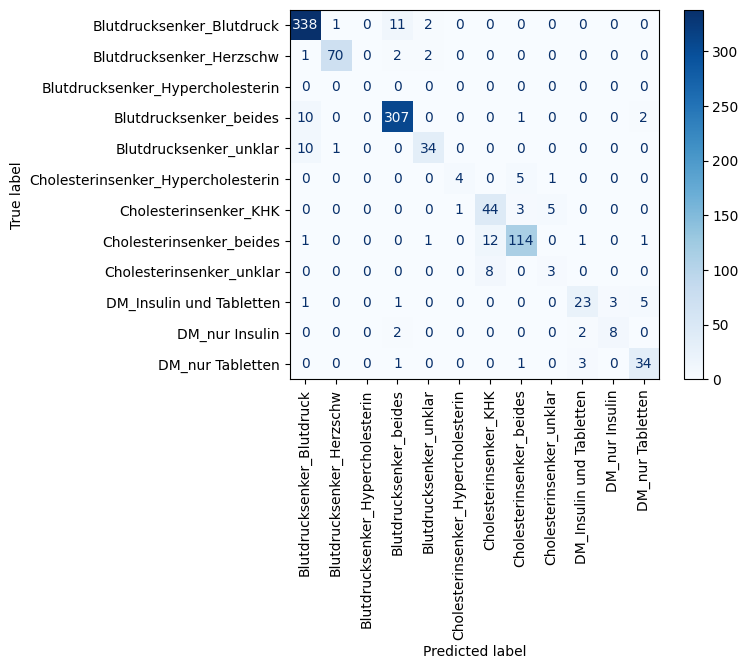

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix=cms,  display_labels=dataset.LE.classes_)
disp.plot(cmap=plt.cm.Blues,values_format='g', xticks_rotation="vertical")
disp.figure_.savefig(f'{SAVEDIR}/{args.bertmodel}_cm.png')